# Titanic Hayatta Kalma Tahmini - Proje Özeti

Bu notebook, Titanic veri seti üzerinde EDA, preprocessing, feature engineering
ve model karşılaştırması sürecimi baştan sona içerir. Aşağıdaki bölümler sırasıyla:
1. Veri Keşfi (EDA)
2. Ön İşleme (Preprocessing)
3. İlk Model (Logistic Regression - Random Forest karşılaştırması)
4. Feature Engineering Denemeleri (family_size, title)
5. Final Model ve Sonuç

In [22]:
import pandas as pd
import seaborn as sns

titanic = sns.load_dataset('titanic')

titanic_clean = titanic.drop(columns=['deck', 'alive', 'class', 'embark_town', 'who', 'adult_male', 'alone'])
titanic_clean['age'] = titanic_clean['age'].fillna(titanic_clean['age'].median())
titanic_clean['embarked'] = titanic_clean['embarked'].fillna(titanic_clean['embarked'].mode()[0])

titanic_clean.head()

titanic_clean['family_size'] = titanic_clean['sibsp'] + titanic_clean['parch'] + 1
titanic_clean[['sibsp', 'parch', 'family_size']].head(10)

,sibsp,parch,family_size
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1
5,0,0,1
6,0,0,1
7,3,1,5
8,0,2,3
9,1,0,2


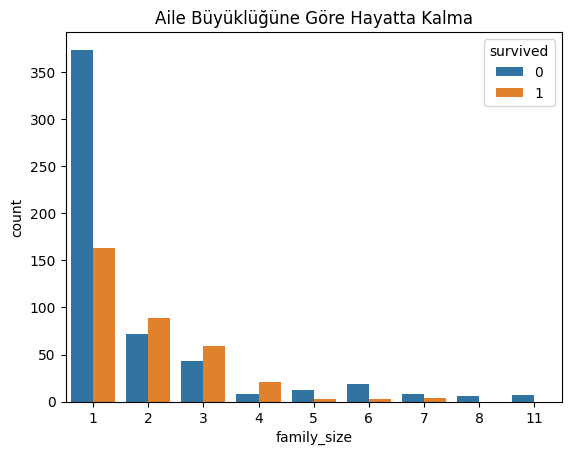

In [23]:
import matplotlib.pyplot as plt

sns.countplot(data=titanic_clean, x='family_size', hue='survived')
plt.title('Aile Büyüklüğüne Göre Hayatta Kalma')
plt.show()

In [24]:
titanic_full = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
titanic_full.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [25]:
titanic_clean['name'] = titanic_full['Name']
titanic_clean['name'].head(10)


,name
0,"Braund, Mr. Owen Harris"
1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,"Heikkinen, Miss. Laina"
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,"Allen, Mr. William Henry"
5,"Moran, Mr. James"
6,"McCarthy, Mr. Timothy J"
7,"Palsson, Master. Gosta Leonard"
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)"
9,"Nasser, Mrs. Nicholas (Adele Achem)"


In [26]:
print(titanic_full['Survived'].head(10).tolist())
print(titanic_clean['survived'].head(10).tolist())

[0, 1, 1, 1, 0, 0, 0, 0, 1, 1]
[0, 1, 1, 1, 0, 0, 0, 0, 1, 1]


In [27]:
titanic_clean['title'] = titanic_clean['name'].str.extract(r',\s*([^\.]+)\.')
titanic_clean['title'].value_counts()

,count
title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [29]:
titanic_clean['title'] = titanic_clean['title'].replace(
    ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'],
    'Rare'
)
titanic_clean['title'] = titanic_clean['title'].replace(['Mlle', 'Ms'], 'Miss')
titanic_clean['title'] = titanic_clean['title'].replace('Mme', 'Mrs')

titanic_clean['title'].value_counts()

titanic_clean['title'] = titanic_clean['title'].replace('the Countess', 'Rare')
titanic_clean['title'].value_counts()

,count
title,
Mr,517
Miss,185
Mrs,126
Master,40
Rare,23


In [30]:
titanic_clean['title'] = titanic_clean['title'].replace('the Countess', 'Rare')
titanic_clean['title'].value_counts()

,count
title,
Mr,517
Miss,185
Mrs,126
Master,40
Rare,23


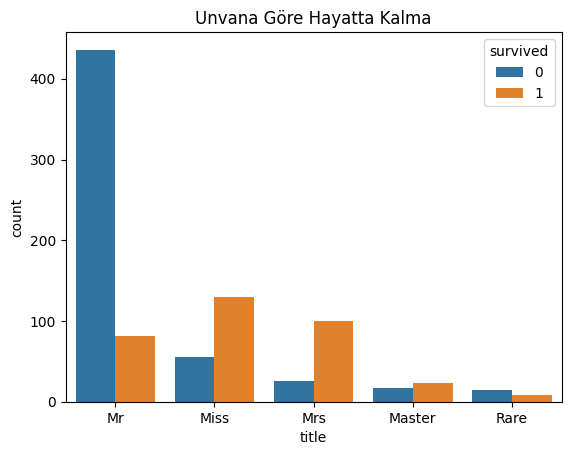

In [31]:
sns.countplot(data=titanic_clean, x='title', hue='survived', order=['Mr', 'Miss', 'Mrs', 'Master', 'Rare'])
plt.title('Unvana Göre Hayatta Kalma')
plt.show()


In [32]:
titanic_model = titanic_clean.drop(columns=['name'])
titanic_model = pd.get_dummies(titanic_model, columns=['title'], drop_first=True)
titanic_model['sex'] = titanic_model['sex'].map({'male': 0, 'female': 1})
titanic_model = pd.get_dummies(titanic_model, columns=['embarked'], drop_first=True)

titanic_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    int64  
 3   age          891 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   family_size  891 non-null    int64  
 8   title_Miss   891 non-null    bool   
 9   title_Mr     891 non-null    bool   
 10  title_Mrs    891 non-null    bool   
 11  title_Rare   891 non-null    bool   
 12  embarked_Q   891 non-null    bool   
 13  embarked_S   891 non-null    bool   
dtypes: bool(6), float64(2), int64(6)
memory usage: 61.0 KB


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = titanic_model.drop(columns=['survived'])
y = titanic_model['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model2 = LogisticRegression(max_iter=1000)
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)
accuracy2 = accuracy_score(y_test, y_pred2)
print(f"Yeni özelliklerle doğruluk oranı: {accuracy2:.2%}")


Yeni özelliklerle doğruluk oranı: 79.33%


In [34]:
X2 = titanic_model.drop(columns=['survived', 'sex'])
y2 = titanic_model['survived']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

model3 = LogisticRegression(max_iter=1000)
model3.fit(X_train2, y_train2)

y_pred3 = model3.predict(X_test2)
accuracy3 = accuracy_score(y_test2, y_pred3)
print(f"Sex çıkarılmış, title ile doğruluk oranı: {accuracy3:.2%}")

Sex çıkarılmış, title ile doğruluk oranı: 79.89%


In [37]:
X3 = titanic_model.drop(columns=['survived', 'sex', 'family_size'])
y3 = titanic_model['survived']

X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size=0.2, random_state=42)

model4 = LogisticRegression(max_iter=1000)
model4.fit(X_train3, y_train3)

y_pred4 = model4.predict(X_test3)
accuracy4 = accuracy_score(y_test3, y_pred4)
print(f"Sadece title (family_size ve sex yok) doğruluk oranı: {accuracy4:.2%}")

Sadece title (family_size ve sex yok) doğruluk oranı: 79.89%


## 🏆 Proje Özeti ve Final Sonuç

**En iyi model:** Logistic Regression — **%81.01 doğruluk (accuracy)**

**Denenen modeller:**
- Logistic Regression (temel özellikler): %81.01 ✅ Final model
- Random Forest (temel özellikler): %79.89
- Logistic Regression + feature engineering (family_size, title): %79.33 - %79.89 arası

**Çıkardığım dersler:**
1. Cinsiyet (sex) ve bilet sınıfı (pclass), hayatta kalmayı belirleyen en güçlü iki özellikti.
2. Daha karmaşık bir algoritma (Random Forest) her zaman daha iyi sonuç vermiyor — küçük, doğrusal ilişkili veri setlerinde basit modeller (Logistic Regression) daha başarılı olabiliyor.
3. Yeni özellik eklemek (family_size, title gibi) her zaman modeli iyileştirmiyor; bazı özellikler birbirleriyle çakışabiliyor (multicollinearity) ve modeli karıştırabiliyor.
4. En iyi yaklaşım, birden fazla modeli ve özellik kombinasyonunu deneyip karşılaştırmaktır — ilk denemede en iyi sonuca ulaşmak beklenmemeli.

**Sonuç:** Bu proje ile bir makine öğrenmesi projesinin uçtan uca akışını (EDA → preprocessing → feature engineering → model eğitimi → karşılaştırma → hata analizi) baştan sona deneyimledim.